In [3]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchsummary import summary
from torch.optim.lr_scheduler import CosineAnnealingLR
from collections import Counter
import time
from sklearn.model_selection import train_test_split

In [51]:
# Setting for the the trianing 
tr_percentage = 0.1# train on provided percetage of data from the entire dataset
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f"Using device: [{device}]")
print(f'Your are using {tr_percentage*100}% of your dataset')


Using device: [cuda]
Your are using 10.0% of your dataset


In [5]:
# Prepare the dataset directories 
# data_path = "food-classification/ifood-2019-fgvc6"
data_path = "/kaggle/input/datasets/hjhgkyo/food-dataset-ifood2019fgvc"
train_data = os.path.join(data_path, 'train_set/train_set')
test_data = os.path.join(data_path, 'val_set/val_set')

train_imgs = os.listdir(train_data) # get all training images files
test_imgs = os.listdir(test_data) # get all training images files
print(f'There are {len(train_imgs)} training and {len(test_imgs)} testing images')

There are 118475 training and 11994 testing images


In [6]:
# read the labels 
pdf = pd.read_csv(os.path.join(data_path, 'train_labels.csv'))
t_pdf = pd.read_csv(os.path.join(data_path, 'val_labels.csv'))
print(f'Ther are {pdf.isna().sum().sum()} images without labels')
pdf.count()

Ther are 0 images without labels


img_name    118475
label       118475
dtype: int64

In [7]:
# read the classes value
data_classes = pd.read_csv(os.path.join(data_path, 'class_list.txt'), sep=' ') 
data_classes.columns = ['id', 'name']
NUM_CLASSES = len(data_classes)+1
# plot the all class distributions 
all_classes = pdf['label']

# Stratified sampling to get xx% from each class
# trainable_pdf = pdf.groupby('label', group_keys=False).sample(frac=tr_percentage, random_state=42)
trainable_pdf = (
    pdf.groupby('label', group_keys=False)
    .apply(lambda x: x.sample(
        max(2, int(len(x) * tr_percentage)),
        random_state=42
    ).assign(label=x.name), include_groups=False)
)

# test_pdf = t_pdf.groupby('label', group_keys=False).sample(frac=tr_percentage, random_state=42)
test_pdf = (
    t_pdf.groupby('label', group_keys=False)
    .apply(lambda x: x.sample(
        max(2, int(len(x) * tr_percentage)),
        random_state=42
    ).assign(label=x.name), include_groups=False)
)

print(f'There are {NUM_CLASSES} classes')
print(f'There are {len(trainable_pdf)} images for training and validation')


There are 251 classes
There are 11732 images for training and validation


In [6]:
# plot the class distribution
def plot_class_distributions(num_labels, percentage = 100):
    """
    This method will plot the labels distribution passed in the histogram format
    """
    counts = Counter(num_labels)
    min_class = min(counts, key=counts.get)
    max_class = max(counts, key=counts.get)

    print(f"""
        Min class: {min_class}  ––> {counts[min_class]} images
        Max class: {max_class} ––> {counts[max_class]} images 
    """)

    plt.figure(figsize=(12, 5))
    plt.hist(num_labels, bins=NUM_CLASSES, color='skyblue', edgecolor='black', alpha=0.8)
    plt.title(f"""
        Distribution of {percentage}% Labels
        Min class: {min_class}  ––> {counts[min_class]} images
        Max class: {max_class} ––> {counts[max_class]} images 
    """)
    plt.xlabel('Label Value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


        Min class: 162  ––> 34 images
        Max class: 218 ––> 656 images 
    


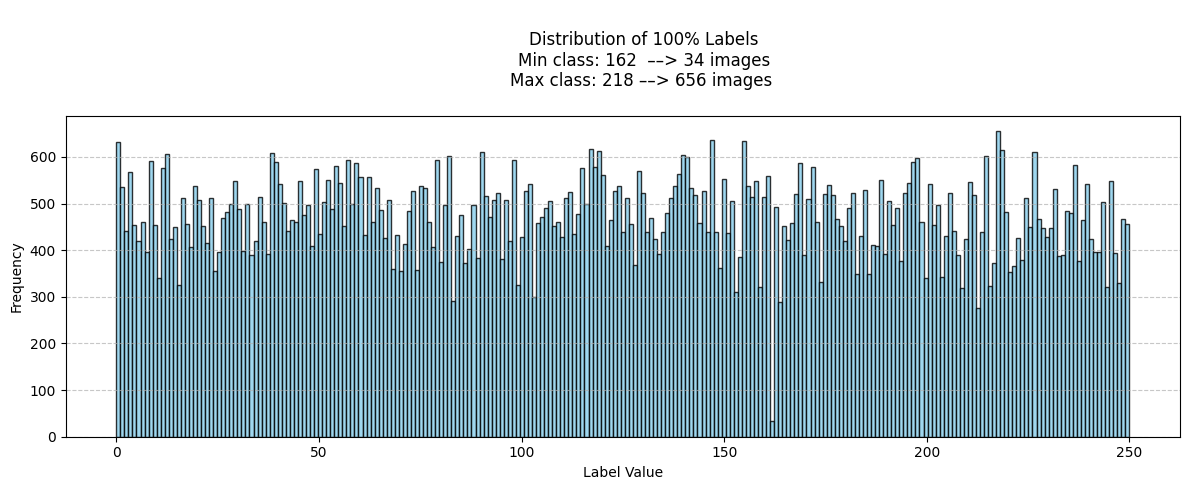

In [7]:
# plot all class distributions 
plot_class_distributions(all_classes)


        Min class: 162  ––> 3 images
        Max class: 218 ––> 65 images 
    


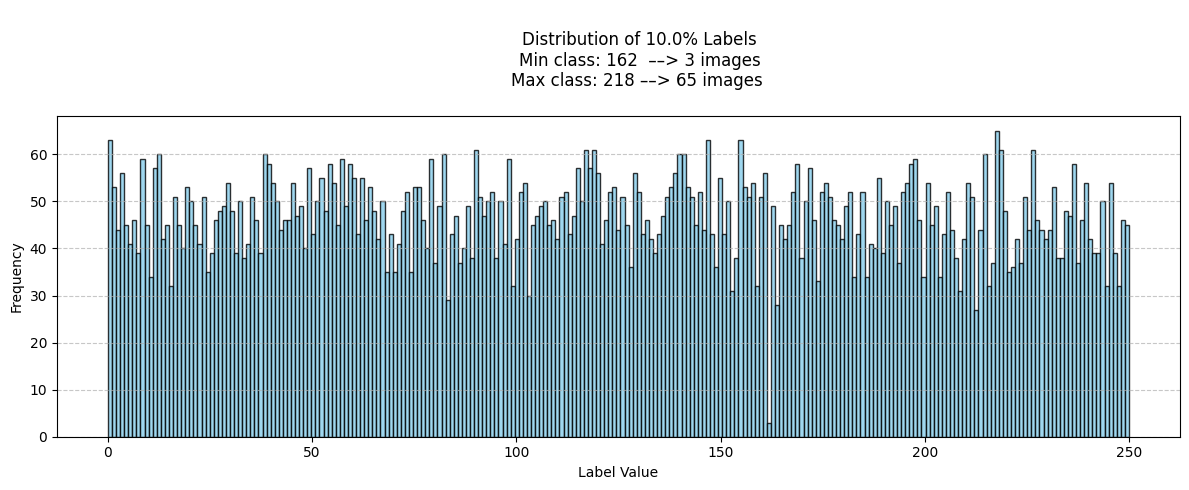

In [8]:
# plot the sampled classes distribution
plot_class_distributions(trainable_pdf['label'], tr_percentage*100)

In [8]:
glb_mean = [0.485, 0.456, 0.406]
glb_std = [0.229, 0.224, 0.225]

In [9]:
class RotationDataset(Dataset):
    def __init__(self, df, dir="train_set/train_set", transform=None):
        self.df = df
        self.dir = dir
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        file = self.df.iloc[idx].values
        img_name = file[0]
        img = Image.open(os.path.join(data_path, self.dir, img_name))
        if self.transform:
            img = self.transform(img)
        # rotate and get lables
        rot_label = torch.randint(0, 4, (1,)).item()
        img = torch.rot90(img, rot_label, dims=[1, 2])
        return img, rot_label

In [10]:
# Create training and validation transform pipeline 
SIZE = 160
train_transform = transforms.Compose([
    transforms.Resize(size=(SIZE, SIZE), interpolation=InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(), 
    
    transforms.RandomCrop(160, padding=8),
    transforms.ToTensor(),
    transforms.Normalize(mean=glb_mean, std=glb_std),
])
val_transform = transforms.Compose([  
    transforms.Resize(size=(SIZE, SIZE), interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(mean=glb_mean, std=glb_std),
])

In [11]:
# split the train dataset in training (75%), validation (25%)
training_df, validation_df = train_test_split(
    trainable_pdf,
    test_size=0.25,
    stratify=trainable_pdf['label'],
    random_state=42
)
print(f'{len(training_df)} images for training \n{len(validation_df)} images for validation \n{len(test_pdf)} images for testinng.')

8799 images for training 
2933 images for validation 
1094 images for testinng.


In [12]:
# Get the training, Validation and testing datas
train_data = RotationDataset(training_df, 'train_set/train_set', train_transform)
val_data = RotationDataset(validation_df, 'train_set/train_set', val_transform)
test_data = RotationDataset(test_pdf, 'val_set/val_set', val_transform)
len(train_data), len(val_data), len(test_data)

(8799, 2933, 1094)

In [14]:
# Add data loader 
BATCH_SIZE = 32
PIN_MEMORY = True if device == 'cuda' or device == 'mps' else False
NUM_WORKERS = 0
train_loader = DataLoader(train_data,
                          batch_size=BATCH_SIZE,
                          shuffle=True, 
                          # sampler=sampler,
                          drop_last=True, 
                          pin_memory=PIN_MEMORY,
                          num_workers=NUM_WORKERS)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, pin_memory=PIN_MEMORY, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, pin_memory=PIN_MEMORY, num_workers=NUM_WORKERS)
print(f"There are \n {len(train_loader)} training batches \n {len(val_loader)} validation batches \n {len(test_loader)} testing batches")

There are 
 274 training batches 
 92 validation batches 
 35 testing batches


## Self-supervised learning
```
        Food Images (ignore labels)
                ↓
        SimCLR-style training
                ↓
        CNN(ResNet style) Encoder learns features
                ↓
        Remove projection head
                ↓
        Extract features
                ↓
        Train SVM / Logistic Regression / CNN Classifier
                ↓
        251 Food Classes
```

In [15]:
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__() 
        
        self.doubleConve = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False), # No bias also save GPU
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True), # Faster with GPU
            nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False), 
            nn.BatchNorm2d(out_ch),
        )
        
        self.skip = nn.Identity()
        if in_ch != out_ch or stride !=1:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, padding=0, bias=False), 
                nn.BatchNorm2d(out_ch),
            ) 
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        residual = self.skip(x)
        out = self.doubleConve(x)
        out = out + residual 
        out = self.relu(out) # added residual
        return out


We set bias=False because it is followed immediately by a Batch Normalization (nn.BatchNorm2d) 

Because the bias is a constant value added to every single pixel in the batch, it directly increases the batch mean (\(\mu \)) by that exact same constant value. When Batch Normalization subtracts the mean (\(\mu \)), the bias value cancels itself out completely.

Turning it off saves GPU memory and speeds up your training iterations.


In [47]:
class ResNet(nn.Module):
    def __init__(self):
        super().__init__()
        # input layer
        self.prep = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        # Encoder
        self.block1 = nn.Sequential(ResidualBlock(32, 32, stride=1), ResidualBlock(32, 32, stride=1))      
        self.block2 = nn.Sequential(ResidualBlock(32, 64, stride=2), ResidualBlock(64, 64, stride=1))      
        self.block3 = nn.Sequential(ResidualBlock(64, 128, stride=2), ResidualBlock(128, 128, stride=1))      
        self.block4 = nn.Sequential(ResidualBlock(128, 256, stride=2), ResidualBlock(256, 256, stride=1))      
        self.block5 = nn.Sequential(ResidualBlock(256, 512, stride=2))      

    def forward(self, x): 
        x = self.prep(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        return x

resnet = ResNet().to(device)
# summary(resnet, input_size=(3, 64, 64))

In [67]:
class RotationNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = ResNet()
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(512, 4)
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.head(x)
        return x
rotationNet = RotationNet().to(device)
# prevents the GPU from wasting time reading and writing intermediate steps to memory.
rotationNet = torch.compile(rotationNet) # Fuses the graph for massive speedups

In [59]:
summary(rotationNet, input_size=(3, 160, 160))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 80, 80]             864
       BatchNorm2d-2           [-1, 32, 80, 80]              64
              ReLU-3           [-1, 32, 80, 80]               0
          Identity-4           [-1, 32, 80, 80]               0
            Conv2d-5           [-1, 32, 80, 80]           9,216
       BatchNorm2d-6           [-1, 32, 80, 80]              64
              ReLU-7           [-1, 32, 80, 80]               0
            Conv2d-8           [-1, 32, 80, 80]           9,216
       BatchNorm2d-9           [-1, 32, 80, 80]              64
             ReLU-10           [-1, 32, 80, 80]               0
    ResidualBlock-11           [-1, 32, 80, 80]               0
         Identity-12           [-1, 32, 80, 80]               0
           Conv2d-13           [-1, 32, 80, 80]           9,216
      BatchNorm2d-14           [-1, 32,

In [69]:
# Setup the model compiler
EPOCHS = 50
optimizer = torch.optim.AdamW(rotationNet.parameters(), lr=1e-3, weight_decay=1e-4) 

# loss method 
loss_fun = nn.CrossEntropyLoss()

# per-epoch stepping
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

In [70]:
# Create a training method for non-labeled data
# avoid gradient magnitudes from being flushed to zero(underfilowing) using 16-bit floating-poin
scaler = torch.amp.GradScaler('cuda') # also speed up training 
def train_model(model, dataloader, loss_fun, optimizer):
  training_loss, total, correct = 0, 0, 0 
  model.train()
  for batch, (X, y), in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    if y.ndim == 2:
        y = y.squeeze(1)
    y = y.long()
    # clears the gradient buffers by setting them to None instead of filling them with zeros 
    optimizer.zero_grad(set_to_none=True) # reduce memory consumption and speed up training 

    # Enable AMP for the forward pass
    with torch.autocast(device_type='cuda', dtype=torch.float16): 
        y_pred = model(X) # (B, C, H, W)
        loss = loss_fun(y_pred, y) # calculate the loss

    # Scale loss and backpropagate
    scaler.scale(loss).backward() # comput the gradient
    scaler.step(optimizer) # update the weight
    scaler.update() # update the scaler for the next iteration
      
    training_loss += loss.item()
    # Calculate the training accuracy
    preds = torch.argmax(y_pred, dim=1)
    correct += (preds == y).sum().item()
    total += y.size(0) 
    
    if (batch+1 == len(dataloader)):
      print(f'Batch {batch+1}/{len(dataloader)} | Loss: {loss.item():.4f}')
  training_acc = correct / total 
  return training_loss/len(dataloader), training_acc, 

In [71]:
# Create a validation method
def validate_model(model, dataloader, loss_fun, epoch):
  model.eval()
  val_loss, correct, total = 0, 0, 0
  with torch.no_grad():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)
      if y.ndim == 2:
        y = y.squeeze(1)
      y = y.long()

      # Enable AMP for the forward pass
      with torch.autocast(device_type='cuda', dtype=torch.float16):
          y_pred = model(X) # (B, C, H, W)
          loss = loss_fun(y_pred, y) # calculate the loss
      
      # y_pred = model(X)
      # loss = loss_fun(y_pred, y)
      val_loss += loss.item() 
      preds = torch.argmax(y_pred, dim=1)
      # accuracy in pixel level
      correct += (preds == y).sum().item()
      total += y.size(0)

    val_acc = correct/total
  return val_loss/len(dataloader), val_acc

In [72]:
output_path = "/kaggle/working"
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [], 
    "lr": [], 
}
best_val_loss = float('inf')

patience, epochs_no_improve = 10, 0
best_val_acc = 0
start_train_time = time.time()
for i in range(EPOCHS):
    print(f'Epoch {i+1}:')
    tr_loss, tr_acc = train_model(rotationNet, train_loader, loss_fun, optimizer)
    history['train_acc'].append(tr_acc)
    history['train_loss'].append(tr_loss) 
    scheduler.step()

    val_loss, val_acc = validate_model(rotationNet, val_loader, loss_fun, i+1)
    history['val_acc'].append(val_acc)
    history['val_loss'].append(val_loss) 
    history['lr'].append(optimizer.param_groups[-1]['lr'])
    

    print(f"""
    tr loss [{tr_loss:.4f}] | val loss [{val_loss:.4f}]
    tr acc [{tr_acc:.4f}] | val acc [{val_acc:.4f}] | lr [{optimizer.param_groups[-1]['lr']:.6f}]
    """) 

    # Save only weights of the best model 
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(rotationNet.state_dict(), f'{output_path}/best_model_weights.pth')
        print("Best model saved!")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {i+1}")
            break
torch.save(rotationNet.state_dict(), f'{output_path}/last_model.pth')
print(f'Last model saved correctly')
end_train_time = time.time()
print(f'End training after {(end_train_time - start_train_time)/60:.4f} minutes')

Epoch 1:
Batch 274/274 | Loss: 1.3388

    tr loss [1.3787] | val loss [1.3329]
    tr acc [0.3327] | val acc [0.3785] | lr [0.000999]
    
Best model saved!
Epoch 2:
Batch 274/274 | Loss: 1.2877

    tr loss [1.2823] | val loss [1.2774]
    tr acc [0.4139] | val acc [0.4095] | lr [0.000996]
    
Best model saved!
Epoch 3:
Batch 274/274 | Loss: 1.2464

    tr loss [1.1805] | val loss [1.2882]
    tr acc [0.4814] | val acc [0.4426] | lr [0.000976]
    
Epoch 6:
Batch 274/274 | Loss: 1.2311

    tr loss [1.1558] | val loss [1.2063]
    tr acc [0.4969] | val acc [0.4790] | lr [0.000965]
    
Epoch 7:
Batch 274/274 | Loss: 1.0302

    tr loss [1.1241] | val loss [1.2681]
    tr acc [0.5161] | val acc [0.4439] | lr [0.000952]
    
Epoch 8:
Batch 274/274 | Loss: 1.1438

    tr loss [1.0922] | val loss [1.1501]
    tr acc [0.5306] | val acc [0.4988] | lr [0.000938]
    
Best model saved!
Epoch 9:
Batch 274/274 | Loss: 1.0705

    tr loss [1.0445] | val loss [1.3274]
    tr acc [0.5591] | val 

<Axes: >

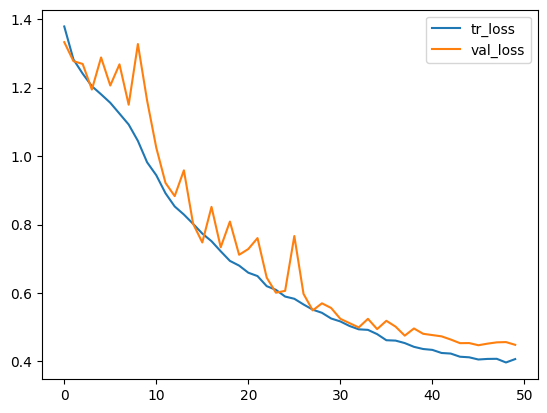

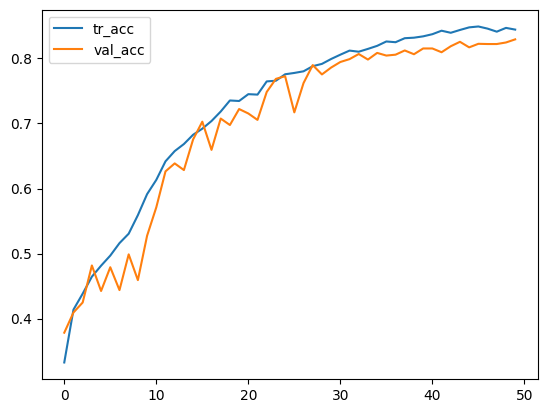

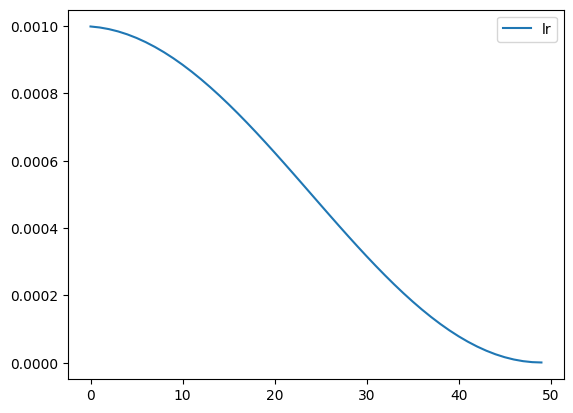

In [73]:
# Plot the learning curve 
pd.DataFrame({'tr_loss': history['train_loss'], 'val_loss': history['val_loss']}).plot()
pd.DataFrame({'tr_acc': history['train_acc'], 'val_acc': history['val_acc']}).plot()
pd.DataFrame({'lr': history['lr']}).plot()